# 10-The Lakehouse Architecture (Iceberg / Delta)

In Lesson 09, we engineered a Distributed Event Streaming Fabric using Apache Kafka to act as a high-throughput shock absorber for our data streams.

Now, we face the final architectural frontier of data engineering: **Where does this data live permanently?**
Historically, enterprises were forced to make a binary, compromised choice:

1. **The Data Lake (S3/GCS/HDFS)**: Infinite, hyper-cheap storage for raw Parquet/JSON files. However, it completely lacked ACID transactions. If a write crashed midway, your files were left in a corrupted state. There was no concept of a schema or an index; queries had to scan petabytes of files blindly.
2. **The Data Warehouse (Snowflake/BigQuery)**: Lightning-fast, optimized transactional computation. However, storage and compute were tightly coupled, leading to massive licensing fees as enterprise data scaled.

To achieve infinite, hyper-cheap storage while maintaining sub-second transactional performance, the industry collapsed these two models into a single modern paradigm: **The Data Lakehouse**.

By overlaying a standardized **Metadata Metadata Table Format (like Apache Iceberg or Delta Lake)** on top of standard, cheap Parquet files, we decouple compute from storage completely.

Let's configure our environment to study the storage layout physics of the Lakehouse.

In [8]:
# Required installations: pip install pyarrow duckdb pandas matplotlib seaborn
import os
import shutil
import pyarrow as pa
import pyarrow.parquet as pq
import duckdb
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Lakehouse Analytics Storage Engine Active.")

✅ Systems Architecture & Lakehouse Analytics Storage Engine Active.


# 1. The Mathematics of Metadata Transaction Logs

A Lakehouse does not rely on a database server to enforce consistency. It enforces consistency using **Immutable State Files**.

Let a Lakehouse table at version $t$ be a collection of columnar physical files on object storage:


$$\mathcal{T}_t = \{f_1, f_2, \dots, f_n\}$$

When an application executes a transaction (e.g., updating 1,000 rows), the Lakehouse engine does not physically modify the existing Parquet files; Parquet files are immutable. Instead, it writes a completely new file containing the mutated rows, and generates a new **Metadata Manifest File** ($M_{t+1}$):

$$M_{t+1} = M_t \setminus \{f_{\text{obsolete}}\} \cup \{f_{\text{new}}\}$$

### The Physics of Time Travel

Because the historical manifest files ($M_0, M_1, \dots, M_t$) are never destroyed, a user can query the database exactly as it existed at any point in historical spacetime.
To query version $t-1$, the engine read parameter simply swaps its pointer to read metadata manifest $M_{t-1}$, completely bypassing the current files. This provides native **Time Travel** and audit capabilities.

# 2. Architecting a Zero-Abstraction Lakehouse Transaction Log

Let's build a functional, zero-abstraction simulation of a Lakehouse storage layout (replicating the underlying file physics of Delta/Iceberg).
We will:

1. Write raw business records into highly compressed, columnar **Parquet files**.
2. Generate an explicit, json-based **Transaction Manifest Ledger** to track active files.
3. Execute an atomic `UPDATE` operation that demonstrates **Copy-On-Write** physics.
4. Execute a **Time Travel Query** to pull data out of a historical state snapshot.

In [9]:
# Create a local clean directory simulating an S3 / MinIO Cloud Storage Bucket
lakehouse_bucket = "./company_lakehouse_storage"
if os.path.exists(lakehouse_bucket):
    shutil.rmtree(lakehouse_bucket)
os.makedirs(lakehouse_bucket)

# --- 🧱 STEP 1: Committing Snapshot v1 (Initial Data Load) ---
print("--- 🪵 Initializing Lakehouse Load (Snapshot v1) ---")

# Define schema and data entries
schema = pa.schema([
    ('user_id', pa.int32()),
    ('username', pa.string()),
    ('balance', pa.float64())
])

data_batch_1 = pa.Table.from_pydict({
    'user_id': [101, 102],
    'username': ['aris', 'bob'],
    'balance': [500.00, 1200.00]
}, schema=schema)

# Physically write the data as an immutable Columnar Parquet File on disk
file_path_1 = f"{lakehouse_bucket}/part-001.parquet"
pq.write_table(data_batch_1, file_path_1)
print(f"   💾 Physical Columnar File written: '{file_path_1}'")

# Generate Metadata Manifest Snapshot v1 (The Log Entry)
manifest_v1 = {
    "version": 1,
    "timestamp": "2026-06-24 12:00:00",
    "active_data_files": [file_path_1]
}
with open(f"{lakehouse_bucket}/v1.metadata.json", "w") as f:
    json.dump(manifest_v1, f, indent=2)
print("   📝 Metadata Manifest Log 'v1.metadata.json' committed securely.")


# --- ⚡ STEP 2: Executing a Copy-On-Write Transaction (Snapshot v2) ---
print("\n--- ⚡ Executing Atomic Update Transaction (Snapshot v2) ---")
print("   User 'aris' updates balance from $500 to $750.")

# In the Lakehouse architecture, we read the old file, mutate it in RAM, 
# and write a COMPLETELY NEW physical file block. We never overwrite files.
data_batch_2 = pa.Table.from_pydict({
    'user_id': [101, 102],
    'username': ['aris', 'bob'],
    'balance': [750.00, 1200.00] # Mutation occurred here
}, schema=schema)

file_path_2 = f"{lakehouse_bucket}/part-002.parquet"
pq.write_table(data_batch_2, file_path_2)
print(f"   💾 Physical Columnar File written: '{file_path_2}'")

# Commit Metadata Manifest Snapshot v2
# We swap the active pointer array. File 1 is now logically deleted, File 2 is active.
manifest_v2 = {
    "version": 2,
    "timestamp": "2026-06-24 15:00:00",
    "active_data_files": [file_path_2] # Pointing to the new block!
}
with open(f"{lakehouse_bucket}/v2.metadata.json", "w") as f:
    json.dump(manifest_v2, f, indent=2)
print("   📝 Metadata Manifest Log 'v2.metadata.json' committed securely.")

--- 🪵 Initializing Lakehouse Load (Snapshot v1) ---
   💾 Physical Columnar File written: './company_lakehouse_storage/part-001.parquet'
   📝 Metadata Manifest Log 'v1.metadata.json' committed securely.

--- ⚡ Executing Atomic Update Transaction (Snapshot v2) ---
   User 'aris' updates balance from $500 to $750.
   💾 Physical Columnar File written: './company_lakehouse_storage/part-002.parquet'
   📝 Metadata Manifest Log 'v2.metadata.json' committed securely.


Now, let's boot a highly decoupled, serverless OLAP execution query compiler (**DuckDB**) to prove we can read any point in historical spacetime by simply altering our manifest read target.

In [10]:
# --- 🚀 STEP 3: Time Travel Query Compilation ---
conn = duckdb.connect()

def query_lakehouse(db_engine, manifest_version: int):
    """Parses the Lakehouse metadata ledger file to compile table views dynamically."""
    manifest_file = f"{lakehouse_bucket}/v{manifest_version}.metadata.json"
    
    with open(manifest_file, "r") as f:
        meta = json.load(f)
    
    # Extract the active files array required for this target timeline
    target_files = meta["active_data_files"]
    
    # Pass the file parameters into DuckDB's vectorized Parquet engine pushdown
    query = f"SELECT * FROM read_parquet({target_files})"
    df = db_engine.execute(query).df()
    return df

print("\n--- ⏳ Executing Time Travel Query: Reading Table State at Version 1 ---")
df_v1 = query_lakehouse(conn, manifest_version=1, )
print(df_v1.to_string())

print("\n--- ⏳ Executing Time Travel Query: Reading Table State at Version 2 ---")
df_v2 = query_lakehouse(conn, manifest_version=2, )
print(df_v2.to_string())

print("\n--- 💡 Engineering Insight ---")
print("Look closely at the folder structure. Both `part-001.parquet` and `part-002.parquet` exist on the disk simultaneously. The actual data query never scanned the filesystem directories; it scanned the metadata json ledger first.")
print("Because the metadata handles the abstraction layer, multiple separate Spark or DuckDB clusters can read from Version 1 while an analytical writer is producing Version 3 simultaneously with zero table locks, zero deadlocks, and zero transactional collision. Complete, infinite decoupling achieved.")


--- ⏳ Executing Time Travel Query: Reading Table State at Version 1 ---
   user_id username  balance
0      101     aris    500.0
1      102      bob   1200.0

--- ⏳ Executing Time Travel Query: Reading Table State at Version 2 ---
   user_id username  balance
0      101     aris    750.0
1      102      bob   1200.0

--- 💡 Engineering Insight ---
Look closely at the folder structure. Both `part-001.parquet` and `part-002.parquet` exist on the disk simultaneously. The actual data query never scanned the filesystem directories; it scanned the metadata json ledger first.
Because the metadata handles the abstraction layer, multiple separate Spark or DuckDB clusters can read from Version 1 while an analytical writer is producing Version 3 simultaneously with zero table locks, zero deadlocks, and zero transactional collision. Complete, infinite decoupling achieved.


# 3. Visualizing Lakehouse Storage Topography

To understand why this decoupled model scales infinitely better than standard data warehouses, let's map out the storage layout graph topology, tracing the explicit path of a query passing through the metadata translation layer.

/tmp/ipykernel_15600/3048823864.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  engine_box = patches.Rectangle((2.5, 5.0), 7.0, 1.2, fill=True, color='#34495e', edgecolor='black', linewidth=2)
/tmp/ipykernel_15600/3048823864.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  lake_box = patches.Rectangle((0.5, 0.5), 11.0, 3.8, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=2, linestyle='--')


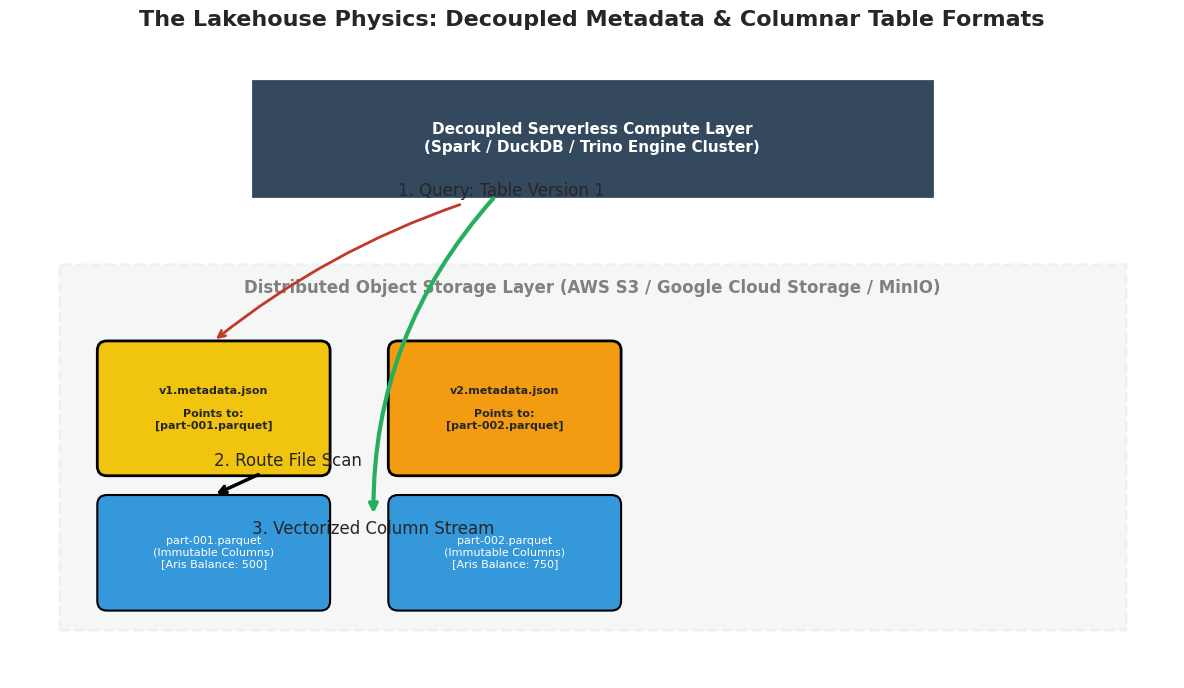

In [11]:
# Visualizing Lakehouse Storage Layout and Time Travel Logic
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("The Lakehouse Physics: Decoupled Metadata & Columnar Table Formats", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Define Compute Engine Layer (The Decoupled Compute)
engine_box = patches.Rectangle((2.5, 5.0), 7.0, 1.2, fill=True, color='#34495e', edgecolor='black', linewidth=2)
ax.add_patch(engine_box)
ax.text(6, 5.6, "Decoupled Serverless Compute Layer\n(Spark / DuckDB / Trino Engine Cluster)", ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# 2. Define Object Storage Layer (The Storage Lake)
lake_box = patches.Rectangle((0.5, 0.5), 11.0, 3.8, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=2, linestyle='--')
ax.add_patch(lake_box)
ax.text(6, 4.0, "Distributed Object Storage Layer (AWS S3 / Google Cloud Storage / MinIO)", ha='center', color='gray', fontweight='bold', fontsize=12)

# Metadata Log Files
ax.add_patch(patches.FancyBboxPatch((1.0, 2.2), 2.2, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f1c40f'))
ax.text(2.1, 2.8, "v1.metadata.json\n\nPoints to:\n[part-001.parquet]", ha='center', va='center', fontweight='bold', fontsize=8)

ax.add_patch(patches.FancyBboxPatch((4.0, 2.2), 2.2, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f39c12'))
ax.text(5.1, 2.8, "v2.metadata.json\n\nPoints to:\n[part-002.parquet]", ha='center', va='center', fontweight='bold', fontsize=8)

# Raw Parquet Data Blocks (The Columnar Bitstream)
ax.add_patch(patches.FancyBboxPatch((1.0, 0.8), 2.2, 1.0, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#3498db'))
ax.text(2.1, 1.3, "part-001.parquet\n(Immutable Columns)\n[Aris Balance: 500]", ha='center', va='center', color='white', fontsize=8)

ax.add_patch(patches.FancyBboxPatch((4.0, 0.8), 2.2, 1.0, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#3498db'))
ax.text(5.1, 1.3, "part-002.parquet\n(Immutable Columns)\n[Aris Balance: 750]", ha='center', va='center', color='white', fontsize=8)

# 3. Draw Execution Directed Edges (The Query Resolution Path)
# Query request for Time Travel V1
ax.annotate("1. Query: Table Version 1", xy=(2.1, 3.5), xytext=(4.0, 5.0), arrowprops=dict(arrowstyle="->", lw=2, color='#c0392b', connectionstyle="arc3,rad=0.1"))

# Metadata routes scan to physical Parquet file 1
ax.annotate("2. Route File Scan", xy=(2.1, 1.9), xytext=(2.1, 2.2), arrowprops=dict(arrowstyle="->", lw=2.5, color='black'))

# Data Streams back up to compute engine directly, bypassing version 2 files completely
ax.annotate("3. Vectorized Column Stream", xy=(5.0, 5.0), xytext=(2.5, 1.5), arrowprops=dict(arrowstyle="<-", lw=3, color='#27ae60', connectionstyle="arc3,rad=-0.2"))

plt.xlim(0, 12)
plt.ylim(0, 6.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the Lakehouse Architecture table formats (Iceberg/Delta) like **A Real Estate Legal Title Registry Ledger vs. Demolishing Houses**:

* **Traditional Data Warehouse (The Demolition Derby)**: You own a physical house (The Table Data). You want to remodel the bathroom (Update a column). In a traditional coupled system, you bring in bulldozers, smash the entire physical wall structure down, and rebuild it inline. While construction is happening, no one can live in the house (Table Locking Bottleneck). If the construction crew drops a structural beam, the entire house is permanently ruined.
* **The Lakehouse Architecture (The Title Ledger)**: You own a plot of land. When you want to update the house, you do not touch or demolish the old house. You build a completely new, modern house right next to it on the open grass **(Write a new Parquet file block)**.
* Once the construction is perfectly complete, you walk down to the City Courthouse **(The Metadata Log Directory)** and file an official title document stamp: *"As of 3:00 PM today, the official corporate address points to House #2. House #1 is now considered a historical heritage site."*
* If a customer walks up to your land looking for you, they check the courthouse registry ledger (The query optimizer reads the JSON manifest). It instantly routes them to House #2. If an internal corporate tax auditor arrives looking to verify what your lifestyle looked like last year, you simply point them to House #1. Both houses exist simultaneously without a single brick ever colliding.

By formalizing the relationship between data engines and storage targets through versioned manifest states, Lakehouse platforms unlock cheap, robust data platforms at massive global scale.